# Air Quality ML Project: Notebook 03
## Binary Classification: "Is this an Unhealthy Hour?" (Track B)

**Goal:** predict a single yes/no flag, `Unhealthy = 1` when PM2.5 > 55.4 µg/m³
(i.e. the *Unhealthy* AQI band or worse).

**What this notebook adds over Notebook 02:**
binary classification unlocks **ROC curves**, **AUC**, **precision–recall curves**
and, most importantly, **decision-threshold analysis**, which none of the
multiclass metrics can express.

**Labs covered:** 4 (Naive Bayes) · 5 (Decision Tree) · 7 (CV + Logistic Regression) ·
8 (SVM) · 9 (Neural Network) · 10 (Random Forest) · 11 (Ensemble)

> Run **Notebook 01** first, this loads the `beijing_aqi_clean.parquet` it produces.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report)

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Load Data & Inspect the Binary Target

Rows with a missing `Unhealthy` value are those with no PM2.5 reading, they have no
ground truth, so they are dropped rather than guessed.

In [2]:
df = pd.read_parquet("beijing_aqi_clean.parquet")
print("Rows loaded:", f"{len(df):,}")
print("Rows with unknown target (no PM2.5):", int(df["Unhealthy"].isna().sum()))

df = df.dropna(subset=["Unhealthy"]).copy()
df["Unhealthy"] = df["Unhealthy"].astype(int)

counts = df["Unhealthy"].value_counts().sort_index()
print("\nClass balance:")
print(f"  0 = Healthy   : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  1 = Unhealthy : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")

Rows loaded: 420,768
Rows with unknown target (no PM2.5): 8739

Class balance:
  0 = Healthy   : 207,119  (50.3%)
  1 = Unhealthy : 204,910  (49.7%)


### 🔍 This target is *balanced*: and that changes the analysis

The 6-class target in Notebook 02 was heavily imbalanced (Hazardous ≈ 4.5%), which is
why we led with macro-F1 there. Here the split is almost exactly 50/50.

**Consequences worth stating:**
- **Accuracy is now a trustworthy headline metric** (it wasn't in Notebook 02).
- **ROC-AUC is well-behaved**. ROC curves can be misleading under heavy imbalance,
  but this is the ideal case for them.
- **No class re-weighting or resampling is needed**, which keeps the comparison clean.

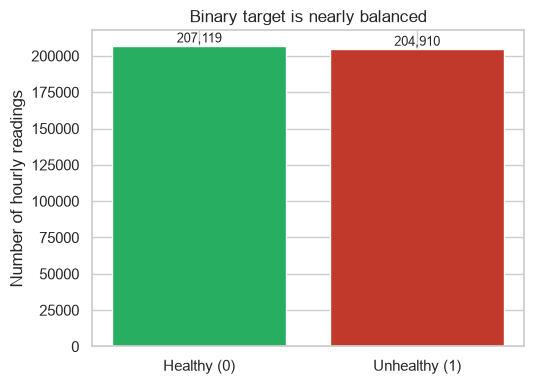

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["Healthy (0)", "Unhealthy (1)"], counts.values, color=["#27ae60", "#c0392b"])
ax.set_ylabel("Number of hourly readings")
ax.set_title("Binary target is nearly balanced")
for i, v in enumerate(counts.values):
    ax.text(i, v*1.01, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 2. Features & the Leakage Rule (again)

`Unhealthy` is a threshold applied to `PM2.5`, so once again **`PM2.5` must be
excluded from the features**, otherwise the model just re-applies the threshold and
scores ~100%.

In [4]:
NUMERIC_FEATURES = ["PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM",
                    "hour_sin","hour_cos","month_sin","month_cos"]
CATEGORICAL_FEATURES = ["wd","station","season"]
TARGET = "Unhealthy"

assert "PM2.5" not in NUMERIC_FEATURES, "PM2.5 must be excluded (leakage)!"
print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features")

14 numeric + 3 categorical features


## 3. Sample Size, Preprocessor & Stratified Split

Same configuration as Notebook 02, `SAMPLE_SIZE = None` uses all ~412k rows, but
keep a sample for the RBF-SVM regardless (its O(n²) cost is algorithmic).

In [5]:
SAMPLE_SIZE = 30_000     # <-- set to None for the full dataset

def stratified_sample(frame, target_col, n, random_state=RANDOM_STATE):
    if n is None or n >= len(frame):
        return frame.copy()
    _, sample = train_test_split(frame, test_size=n/len(frame),
                                 stratify=frame[target_col], random_state=random_state)
    return sample

def build_preprocessor(numeric_features=NUMERIC_FEATURES,
                       categorical_features=CATEGORICAL_FEATURES):
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale",  StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                     sparse_output=False))])
    return ColumnTransformer([("num", numeric, numeric_features),
                              ("cat", categorical, categorical_features)])

data = stratified_sample(df, TARGET, SAMPLE_SIZE)
X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Working set:", f"{len(data):,}", "rows")
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Positive rate — train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

Working set: 30,000 rows
Train: (24000, 17)  Test: (6000, 17)
Positive rate — train: 0.497 | test: 0.497


## 4. Evaluation Helpers (now with probability scores)

For ROC and PR curves we need a **continuous score**, not just the hard 0/1 prediction.

- Most models expose `predict_proba`.
- A plain `SVC` does **not** (unless `probability=True`, which is ~5× slower because
  it runs internal Platt-scaling CV). Instead we use its `decision_function`, 
  the signed distance to the hyperplane, which ranks just as well for ROC-AUC.

`get_scores` below handles both transparently.

In [6]:
def get_scores(fitted_pipe, X):
    """Continuous score for ROC/PR: predict_proba if available, else decision_function."""
    if hasattr(fitted_pipe, "predict_proba"):
        return fitted_pipe.predict_proba(X)[:, 1]
    return fitted_pipe.decision_function(X)


def evaluate_binary(name, pipe, X_tr, y_tr, X_te, y_te, verbose=True):
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    fit_time = time.time() - t0

    y_pred  = pipe.predict(X_te)
    y_score = get_scores(pipe, X_te)

    res = {
        "Model":     name,
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall":    recall_score(y_te, y_pred, zero_division=0),
        "F1":        f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_te, y_score),
        "Fit (s)":   round(fit_time, 1),
    }
    if verbose:
        print(f"{name:22s} acc={res['Accuracy']:.3f}  F1={res['F1']:.3f}  AUC={res['ROC-AUC']:.3f}  ({fit_time:.1f}s)")
    return res, y_pred, y_score


def plot_confusion_binary(y_true, y_pred, title, ax=None, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    fmt = "d"
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True); fmt = ".2f"
    if ax is None:
        _, ax = plt.subplots(figsize=(5.2, 4.4))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                xticklabels=["Healthy", "Unhealthy"],
                yticklabels=["Healthy", "Unhealthy"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    return ax

print("Helpers defined.")

Helpers defined.


## 5. Baseline Models

In [7]:
baseline_models = {
    "Naive Bayes":         GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                  random_state=RANDOM_STATE),
    "SVM (RBF)":           SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Neural Net (MLP)":    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                                         random_state=RANDOM_STATE),
}

results, preds, scores, fitted = [], {}, {}, {}
for name, model in baseline_models.items():
    pipe = Pipeline([("pre", build_preprocessor()), ("model", model)])
    res, pred, score = evaluate_binary(name, pipe, X_train, y_train, X_test, y_test)
    results.append(res); preds[name] = pred; scores[name] = score; fitted[name] = pipe

baseline_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
baseline_df.round(3)

Naive Bayes            acc=0.803  F1=0.806  AUC=0.888  (0.1s)
Logistic Regression    acc=0.904  F1=0.903  AUC=0.966  (0.1s)
Decision Tree          acc=0.883  F1=0.881  AUC=0.883  (0.1s)
Random Forest          acc=0.918  F1=0.918  AUC=0.977  (0.2s)
SVM (RBF)              acc=0.915  F1=0.915  AUC=0.975  (2.1s)
Neural Net (MLP)       acc=0.893  F1=0.894  AUC=0.964  (6.7s)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Fit (s)
3,Random Forest,0.918,0.916,0.920,0.918,0.977,0.2
4,SVM (RBF),0.915,0.916,0.913,0.915,0.975,2.1
1,Logistic Regression,0.904,0.906,0.900,0.903,0.966,0.1
5,Neural Net (MLP),0.893,0.882,0.906,0.894,0.964,6.7
0,Naive Bayes,0.803,0.792,0.820,0.806,0.888,0.1
2,Decision Tree,0.883,0.890,0.873,0.881,0.883,0.1


## 6. ROC Curves: All Models on One Axis

The ROC curve plots **true-positive rate vs false-positive rate** across *every*
possible decision threshold. It answers a question a single accuracy number cannot:
*how good is this model at ranking unhealthy hours above healthy ones, regardless of
where we draw the line?*

The diagonal is random guessing (AUC = 0.5); the top-left corner is perfect.

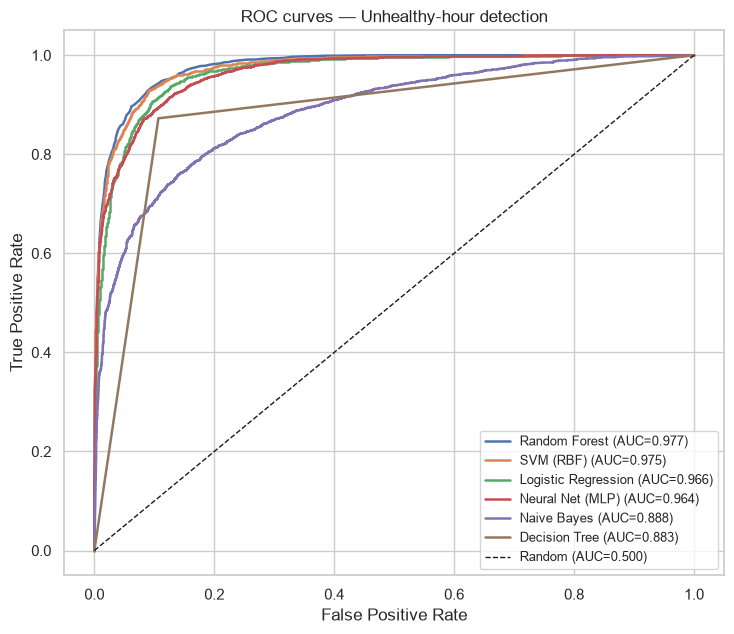

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name in baseline_df["Model"]:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    auc = roc_auc_score(y_test, scores[name])
    ax.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — Unhealthy-hour detection")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

### Precision–Recall curves
PR curves focus on the positive class only. With a balanced target the two views agree,
but PR is the one to lead with whenever the positive class is rare, worth showing
that the distinction is understood.

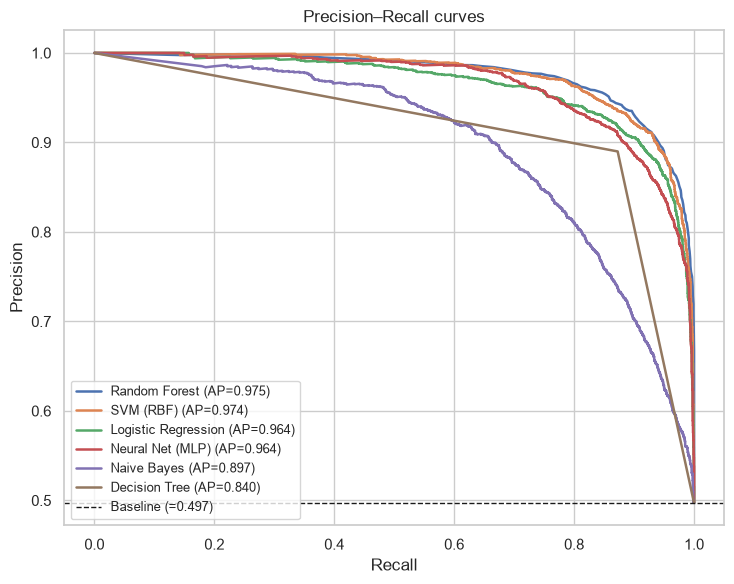

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for name in baseline_df["Model"]:
    prec, rec, _ = precision_recall_curve(y_test, scores[name])
    ap = average_precision_score(y_test, scores[name])
    ax.plot(rec, prec, lw=1.8, label=f"{name} (AP={ap:.3f})")

ax.axhline(y_test.mean(), color="k", ls="--", lw=1,
           label=f"Baseline (={y_test.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curves")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

## 7. Confusion Matrix of the Best Baseline

Best baseline (by ROC-AUC): Random Forest


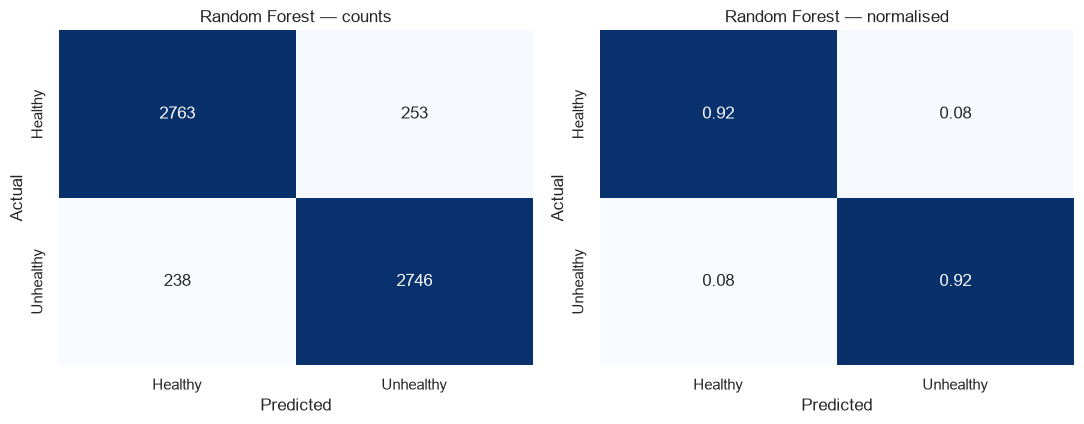

              precision    recall  f1-score   support

     Healthy       0.92      0.92      0.92      3016
   Unhealthy       0.92      0.92      0.92      2984

    accuracy                           0.92      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.92      0.92      0.92      6000



In [10]:
best_baseline = baseline_df.iloc[0]["Model"]
print("Best baseline (by ROC-AUC):", best_baseline)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
plot_confusion_binary(y_test, preds[best_baseline], f"{best_baseline} — counts", ax=axes[0])
plot_confusion_binary(y_test, preds[best_baseline], f"{best_baseline} — normalised",
                      ax=axes[1], normalize=True)
plt.tight_layout(); plt.show()

print(classification_report(y_test, preds[best_baseline],
                            target_names=["Healthy", "Unhealthy"], zero_division=0))

## 8. Hyperparameter Tuning (cross-validated)

Identical strategy to Notebook 02, but now scored on **ROC-AUC**. the natural
criterion for a binary ranker, and independent of any particular threshold.

In [11]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_results, tuned_preds, tuned_scores, best_params, best_estimators = [], {}, {}, {}, {}

def tune(name, model, param_grid, search="grid", n_iter=6,
         X_tr=X_train, y_tr=y_train):
    pipe = Pipeline([("pre", build_preprocessor()), ("model", model)])
    kwargs = dict(estimator=pipe, scoring="roc_auc", cv=cv, n_jobs=-1)
    srch = (GridSearchCV(param_grid=param_grid, **kwargs) if search == "grid"
            else RandomizedSearchCV(param_distributions=param_grid, n_iter=n_iter,
                                    random_state=RANDOM_STATE, **kwargs))
    t0 = time.time(); srch.fit(X_tr, y_tr); elapsed = time.time() - t0

    est     = srch.best_estimator_
    y_pred  = est.predict(X_test)
    y_score = get_scores(est, X_test)
    label   = name + " (tuned)"
    res = {"Model": label,
           "Accuracy":  accuracy_score(y_test, y_pred),
           "Precision": precision_score(y_test, y_pred, zero_division=0),
           "Recall":    recall_score(y_test, y_pred, zero_division=0),
           "F1":        f1_score(y_test, y_pred, zero_division=0),
           "ROC-AUC":   roc_auc_score(y_test, y_score),
           "Fit (s)":   round(elapsed, 1)}
    print(f"{name}: best CV AUC={srch.best_score_:.3f} | test AUC={res['ROC-AUC']:.3f} | {elapsed:.0f}s")
    print("   best params:", srch.best_params_)

    tuned_results.append(res); tuned_preds[label] = y_pred
    tuned_scores[label] = y_score; best_params[name] = srch.best_params_
    best_estimators[name] = est
    return est

print("Tuning helper ready.")

Tuning helper ready.


### 8.1 Decision Tree: `GridSearchCV`

In [12]:
dt_best = tune("Decision Tree", DecisionTreeClassifier(random_state=RANDOM_STATE),
               {"model__max_depth": [6, 10, 16, None],
                "model__min_samples_leaf": [1, 5, 20]})

Decision Tree: best CV AUC=0.969 | test AUC=0.964 | 3s
   best params: {'model__max_depth': 6, 'model__min_samples_leaf': 20}


### 8.2 Logistic Regression: `GridSearchCV`

In [13]:
lr_best = tune("Logistic Regression",
               LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
               {"model__C": [0.01, 0.1, 1.0, 10.0]})

Logistic Regression: best CV AUC=0.968 | test AUC=0.966 | 0s
   best params: {'model__C': 0.1}


### 8.3 Random Forest: `RandomizedSearchCV`

In [14]:
rf_best = tune("Random Forest",
               RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
               {"model__n_estimators":     [100, 200, 300],
                "model__max_depth":        [10, 20, None],
                "model__max_features":     ["sqrt", "log2"],
                "model__min_samples_leaf": [1, 2, 5]},
               search="random", n_iter=6)

Random Forest: best CV AUC=0.980 | test AUC=0.977 | 3s
   best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}


### 8.4 SVM: tuned on a reduced stratified subset
Documented trade-off: each SVM fit is O(n²), so tuning happens on 8,000 rows while
evaluation stays on the full test set.

In [15]:
svm_train = stratified_sample(pd.concat([X_train, y_train], axis=1), TARGET, 8_000)
X_svm = svm_train[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_svm = svm_train[TARGET]
print("SVM tuning subset:", X_svm.shape)

svm_best = tune("SVM (RBF)", SVC(kernel="rbf", random_state=RANDOM_STATE),
                {"model__C": [0.5, 1, 5, 10], "model__gamma": ["scale", 0.01, 0.1]},
                search="random", n_iter=4, X_tr=X_svm, y_tr=y_svm)

SVM tuning subset: (8000, 17)
SVM (RBF): best CV AUC=0.974 | test AUC=0.970 | 1s
   best params: {'model__gamma': 0.01, 'model__C': 10}


## 9. Voting Ensemble (Lab 11)

In [16]:
voting = VotingClassifier(
    estimators=[("dt", dt_best.named_steps["model"]),
                ("lr", lr_best.named_steps["model"]),
                ("rf", rf_best.named_steps["model"])],
    voting="soft", n_jobs=-1)

pipe_vote = Pipeline([("pre", build_preprocessor()), ("model", voting)])
res, pred, score = evaluate_binary("Voting Ensemble", pipe_vote,
                                   X_train, y_train, X_test, y_test)
tuned_results.append(res); tuned_preds["Voting Ensemble"] = pred
tuned_scores["Voting Ensemble"] = score

Voting Ensemble        acc=0.915  F1=0.915  AUC=0.975  (0.5s)


## 10. ⭐ Decision-Threshold Analysis

**This is the section that only binary classification makes possible, and it is the
most report-worthy idea in the notebook.**

Every classifier above used the default rule *"predict Unhealthy if probability > 0.50"*.
But 0.50 is an arbitrary convention, not a law. For a **public-health warning system**
the two errors are not equally costly:

- **False negative**. an unhealthy hour goes unflagged → vulnerable people get no warning. **Serious.**
- **False positive**. a healthy hour is flagged → an unnecessary advisory. **Annoying but cheap.**

So we should deliberately lower the threshold to buy **recall** at the cost of some
precision. Let's see the trade-off explicitly.

In [17]:
best_model_name = max(tuned_scores, key=lambda k: roc_auc_score(y_test, tuned_scores[k]))
s = tuned_scores[best_model_name]
print("Using best model for threshold analysis:", best_model_name)

# decision_function scores aren't probabilities; min-max them to [0,1] if needed
if s.min() < 0 or s.max() > 1:
    s = (s - s.min()) / (s.max() - s.min())

rows = []
for t in np.arange(0.05, 0.96, 0.05):
    yp = (s >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    rows.append({"Threshold": round(t, 2),
                 "Precision": precision_score(y_test, yp, zero_division=0),
                 "Recall":    recall_score(y_test, yp, zero_division=0),
                 "F1":        f1_score(y_test, yp, zero_division=0),
                 "Missed unhealthy (FN)": fn,
                 "False alarms (FP)":     fp})

thr_df = pd.DataFrame(rows)
thr_df.round(3)

Using best model for threshold analysis: Random Forest (tuned)


,Threshold,Precision,Recall,F1,Missed unhealthy (FN),False alarms (FP)
0,0.05,0.687,1.000,0.815,1,1356
1,0.10,0.743,0.997,0.851,8,1032
2,0.15,0.779,0.992,0.873,23,838
3,0.20,0.808,0.987,0.889,38,700
4,0.25,0.831,0.982,0.900,53,596
5,0.30,0.852,0.975,0.909,76,506
6,0.35,0.869,0.963,0.914,109,434
7,0.40,0.885,0.953,0.918,140,371
8,0.45,0.900,0.941,0.920,177,311
9,0.50,0.919,0.923,0.921,230,244


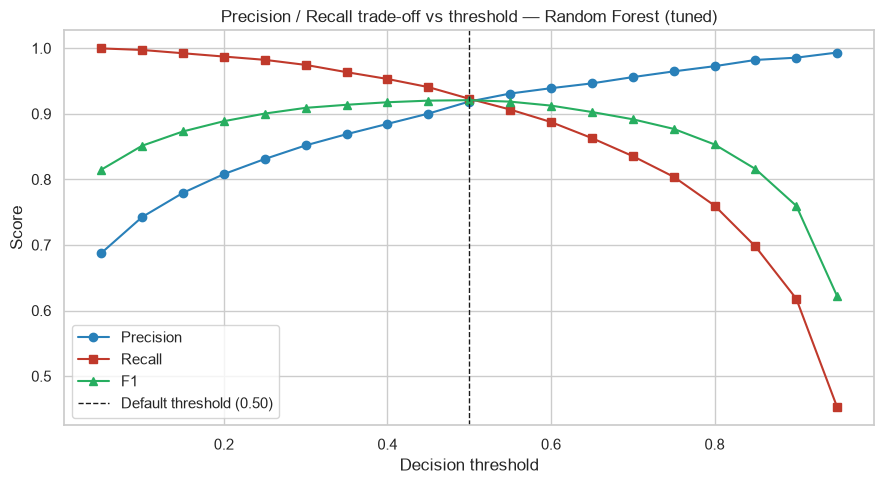

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr_df["Threshold"], thr_df["Precision"], "o-", label="Precision", color="#2980b9")
ax.plot(thr_df["Threshold"], thr_df["Recall"],    "s-", label="Recall",    color="#c0392b")
ax.plot(thr_df["Threshold"], thr_df["F1"],        "^-", label="F1",        color="#27ae60")
ax.axvline(0.5, color="k", ls="--", lw=1, label="Default threshold (0.50)")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall trade-off vs threshold — {best_model_name}")
ax.legend(); plt.tight_layout(); plt.show()

### Choosing a threshold from a stated policy

Instead of eyeballing the curve, we state the requirement first, *"a health-warning
system must catch at least **98%** of unhealthy hours"*, and then pick the threshold
that meets it **at the least cost in false alarms** (i.e. the highest qualifying
threshold). Stating the policy up front is what turns a metric into a decision.

Note the 98% floor is deliberately demanding: at a lax floor like 90% the default
0.50 threshold already qualifies, and there is nothing to decide.

In [19]:
TARGET_RECALL = 0.98        # public-health policy: miss at most 2% of unhealthy hours

default = thr_df.iloc[(thr_df["Threshold"] - 0.50).abs().argmin()]
eligible = thr_df[thr_df["Recall"] >= TARGET_RECALL]

print(f"Policy: recall >= {TARGET_RECALL:.0%}  (model: {best_model_name})")
print()

if eligible.empty:
    print(f"No scanned threshold reaches recall >= {TARGET_RECALL:.0%}.")
    print(f"Best achievable recall was {thr_df['Recall'].max():.3f} "
          f"at threshold {thr_df.loc[thr_df['Recall'].idxmax(), 'Threshold']:.2f}.")
else:
    # highest qualifying threshold = meets the recall floor with the fewest false alarms
    chosen = eligible.iloc[-1]

    for lbl, row in [("Default (0.50)", default), (f"Chosen ({chosen['Threshold']:.2f})", chosen)]:
        print(f"  {lbl:16s} recall={row['Recall']:.3f}  precision={row['Precision']:.3f}  "
              f"missed={int(row['Missed unhealthy (FN)']):,}  false alarms={int(row['False alarms (FP)']):,}")

    d_fn = int(default["Missed unhealthy (FN)"] - chosen["Missed unhealthy (FN)"])   # >0 = fewer missed
    d_fp = int(chosen["False alarms (FP)"] - default["False alarms (FP)"])           # >0 = more alarms

    print()
    if d_fn > 0:
        print(f"  => Catches {d_fn:,} MORE unhealthy hours, at the cost of "
              f"{abs(d_fp):,} {'more' if d_fp > 0 else 'fewer'} false alarms.")
        if d_fn > 0 and d_fp > 0:
            print(f"     Roughly {d_fp/d_fn:.1f} extra false alarms per additional unhealthy hour caught.")
    else:
        print("  => The default threshold already satisfies this policy; no change needed.")



Policy: recall >= 98%  (model: Random Forest (tuned))

  Default (0.50)   recall=0.923  precision=0.919  missed=230  false alarms=244
  Chosen (0.25)    recall=0.982  precision=0.831  missed=53  false alarms=596

  => Catches 177 MORE unhealthy hours, at the cost of 352 more false alarms.
     Roughly 2.0 extra false alarms per additional unhealthy hour caught.


## 11. Feature Importance (tuned Random Forest)

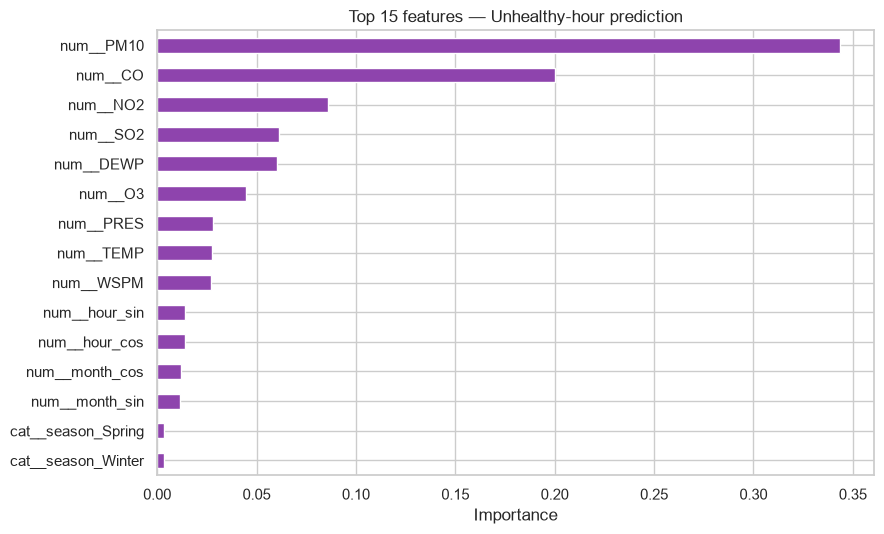

In [20]:
rf_model  = rf_best.named_steps["model"]
feat_names = rf_best.named_steps["pre"].get_feature_names_out()
imp = (pd.Series(rf_model.feature_importances_, index=feat_names)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5.5))
imp.sort_values().plot(kind="barh", color="#8e44ad", ax=ax)
ax.set_title("Top 15 features — Unhealthy-hour prediction")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

## 12. Final Comparison

In [21]:
final_df = (pd.concat([baseline_df, pd.DataFrame(tuned_results)], ignore_index=True)
              .sort_values("ROC-AUC", ascending=False).reset_index(drop=True))
final_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Fit (s)
0,Random Forest,0.918,0.916,0.920,0.918,0.977,0.2
1,Random Forest (tuned),0.921,0.919,0.923,0.921,0.977,3.3
2,Voting Ensemble,0.916,0.912,0.918,0.915,0.975,0.5
3,SVM (RBF),0.915,0.916,0.913,0.915,0.975,2.1
4,SVM (RBF) (tuned),0.910,0.915,0.901,0.908,0.970,0.8
5,Logistic Regression,0.904,0.906,0.900,0.903,0.966,0.1
6,Logistic Regression (tuned),0.903,0.907,0.897,0.902,0.966,0.2
7,Decision Tree (tuned),0.897,0.889,0.906,0.897,0.964,2.6
8,Neural Net (MLP),0.893,0.882,0.906,0.894,0.964,6.7
9,Naive Bayes,0.803,0.792,0.820,0.806,0.888,0.1


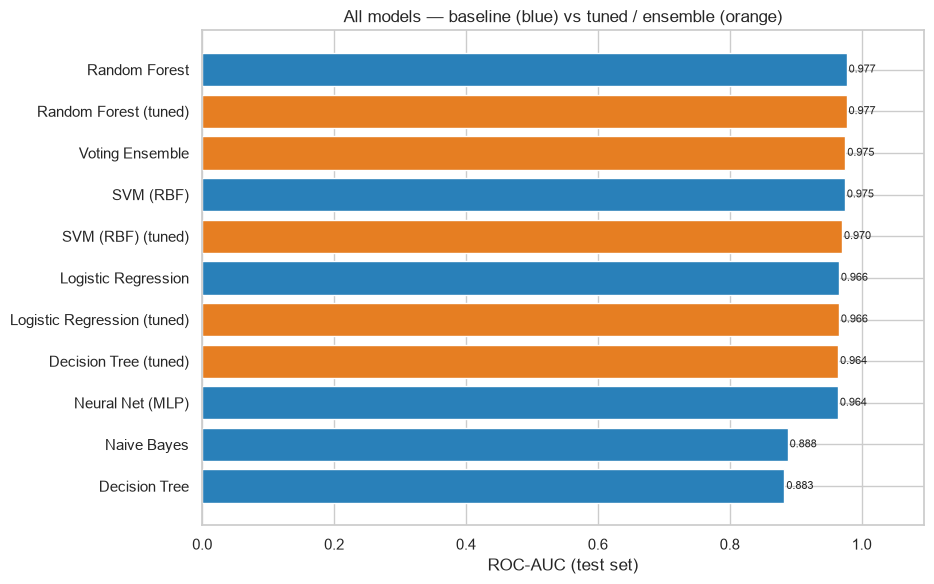

Best model: Random Forest
Accuracy     0.918
Precision    0.916
Recall        0.92
F1           0.918
ROC-AUC      0.977


In [22]:
fig, ax = plt.subplots(figsize=(9.5, 6))
d = final_df.sort_values("ROC-AUC")
colors = ["#e67e22" if ("tuned" in m or "Ensemble" in m) else "#2980b9" for m in d["Model"]]
ax.barh(d["Model"], d["ROC-AUC"], color=colors)
ax.set_xlabel("ROC-AUC (test set)")
ax.set_title("All models — baseline (blue) vs tuned / ensemble (orange)")
for i, v in enumerate(d["ROC-AUC"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, max(d["ROC-AUC"]) * 1.12)
plt.tight_layout(); plt.show()

print("Best model:", final_df.iloc[0]["Model"])
print(final_df.iloc[0][["Accuracy","Precision","Recall","F1","ROC-AUC"]].round(3).to_string())

### Best hyperparameters found

In [23]:
for model, params in best_params.items():
    print(f"{model:22s}", {k.replace('model__',''): v for k, v in params.items()})

Decision Tree          {'max_depth': 6, 'min_samples_leaf': 20}
Logistic Regression    {'C': 0.1}
Random Forest          {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
SVM (RBF)              {'gamma': 0.01, 'C': 10}


## Summary

**Covered here:**
- Seven algorithms on the binary "unhealthy hour" target, all in leakage-safe pipelines
- **ROC curves + AUC** and **precision–recall curves** for every model
- Cross-validated tuning (`GridSearchCV` + `RandomizedSearchCV`) scored on ROC-AUC
- **Decision-threshold analysis** driven by an explicit public-health policy

**Findings established here:**
1. **Balanced and imbalanced targets need different headline metrics.** Notebook 02
   needed macro-F1; here accuracy and ROC-AUC are both trustworthy. Same data,
   different framing, different right answer.
2. **The 0.50 threshold is a convention, not a result.** Tuning it is free accuracy-
   for-recall trading, and the correct setting depends on the *cost of each error*, 
   a domain judgement, not a statistical one.
3. **ROC vs PR curves:** ROC is reliable here because classes are balanced; under a
   rare positive class, PR/average-precision is the more honest view.
4. Binary framing is easier than the 6-class problem, expect noticeably higher scores
   than Notebook 02, since the model only has to find one boundary instead of five.

**Next, Notebook 04: Regression** (predicting PM2.5 concentration): MLR, Polynomial,
**Ridge / Lasso / ElasticNet**, SVR, Random-Forest and MLP regressors, evaluated with
RMSE / MAE / R² and residual diagnostics.
